In [ ]:
import os
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/lethality/miniconda3/envs/tf-gpu-new/lib"

import tensorflow as tf
tf.config.optimizer.set_jit(False)

# ✅ Set memory growth immediately after import
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth enabled ✅")

# ✅ Set mixed precision immediately
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled ✅")

print("TF version:", tf.__version__)
print("GPUs:", gpus)


In [ ]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
b = tf.constant([[5.0, 6.0], [7.0, 8.0]])
c = tf.matmul(a, b)
print("Test tensor device:", c.device)
print("Result:\n", c.numpy())

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib
import tensorflow as tf
from tensorflow.keras import layers, Model

# =====================================================
# 1️⃣ LOAD DATA
# =====================================================
df1 = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_cleaned.csv")
df2 = pd.read_csv("Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_cleaned.csv")
df3 = pd.read_csv("Friday-WorkingHours-Morning.pcap_ISCX_cleaned.csv")
df4 = pd.read_csv("Monday-WorkingHours.pcap_ISCX_cleaned.csv")
df5 = pd.read_csv("Tuesday-WorkingHours.pcap_ISCX_cleaned.csv")

# =====================================================
# 2️⃣ MERGE DATA
# =====================================================
df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

min_len = len(df)
df = df.iloc[:min_len].reset_index(drop=True)

# =====================================================
# 3️⃣ SELECT FEATURES (HYBRID)
# =====================================================
df_net = df[[
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets'
]]


print("Dataset preview:\n", df.head())

# =====================================================
# 4️⃣ CLEAN DATA
# =====================================================
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# Clip extreme values (important for CICIDS)
df_hybrid = df.clip(lower=-1e6, upper=1e6)

# =====================================================
# 5️⃣ NORMALIZATION
# =====================================================
data = df.values.astype(np.float32)

print("\nBefore scaling:")
print("Min:", data.min(axis=0))
print("Max:", data.max(axis=0))

data = df.values.astype(np.float32)

scaler = MinMaxScaler()
data = scaler.fit_transform(data)
data = np.clip(data, 0, 1)

# HARD CHECK
assert np.all(data >= 0) and np.all(data <= 1), "Scaling failed!"

joblib.dump(scaler, "scaler_hybrid.save")

print("\nAfter scaling:")
print("Min:", data.min(axis=0))
print("Max:", data.max(axis=0))

# =====================================================
# 6️⃣ SEQUENCE CREATION
# =====================================================
def create_sequences(data, seq_len=24):
    return np.array(
        [data[i:i+seq_len] for i in range(len(data) - seq_len)],
        dtype=np.float32
    )

seq_len = 24
X = create_sequences(data, seq_len)

print("Sequence shape:", X.shape)

# =====================================================
# 7️⃣ SAVE
# =====================================================
np.save("hybrid_sequences.npy", X)
print("Saved hybrid_sequences.npy ✅")

# =====================================================
# 8️⃣ SANITY CHECK
# =====================================================
print("\n--- DATASET SANITY CHECK ---")

print("NaNs:", np.isnan(X).sum())
print("Infs:", np.isinf(X).sum())
print("Min:", X.min(), "| Max:", X.max())

flat = X.reshape(-1, X.shape[-1])
stds = flat.std(axis=0)
print("Constant features:", np.where(stds < 1e-6)[0])

print("Mean:", X.mean(), "| Std:", X.std())

seq_std = X.std(axis=(1,2))
print("Dead sequences:", np.sum(seq_std < 1e-6))

# =====================================================
# 9️⃣ LEARNABILITY TEST
# =====================================================
print("\n--- GAN DATA LEARNABILITY TEST ---")

X_test = X[:10000]

inputs = layers.Input(shape=(seq_len, X.shape[2]))
x = layers.GRU(32, return_sequences=True)(inputs)
x = layers.GRU(32, return_sequences=True)(x)
outputs = layers.TimeDistributed(
    layers.Dense(X.shape[2], activation='sigmoid')
)(x)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    X_test, X_test,
    epochs=5,
    batch_size=256,
    verbose=1
)

print("\nFinal Reconstruction Loss:", history.history['loss'][-1])

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

X = np.load("hybrid_sequences.npy")
idx = np.random.choice(len(X), 50000, replace=False)
X_small = X[idx]
X_train = X_small.astype(np.float32)
print("Training Shape:", X_train.shape)

seq_len    = X_train.shape[1]
n_features = X_train.shape[2]
hidden_dim = 64
latent_dim = 24
batch_size = 128

dataset = (tf.data.Dataset
           .from_tensor_slices(X_train)
           .cache()
           .shuffle(50000)
           .batch(batch_size)
           .prefetch(tf.data.AUTOTUNE))

def build_embedder():
    inputs = layers.Input(shape=(seq_len, n_features))
    x = layers.GRU(hidden_dim, return_sequences=True, dropout=0.2,
                   recurrent_initializer='glorot_uniform')(inputs)
    x = layers.LayerNormalization()(x)
    x = layers.GRU(hidden_dim, return_sequences=True, dropout=0.2,
                   recurrent_initializer='glorot_uniform')(x)
    x = layers.Activation('linear', dtype='float32')(x)
    return Model(inputs, x, name="Embedder")

def build_recovery():
    inputs = layers.Input(shape=(seq_len, hidden_dim))
    x = layers.GRU(hidden_dim, return_sequences=True, dropout=0.2,
                   recurrent_initializer='glorot_uniform')(inputs)
    x = layers.LayerNormalization()(x)
    outputs = layers.TimeDistributed(
        layers.Dense(n_features, activation='sigmoid', dtype='float32')
    )(x)
    return Model(inputs, outputs, name="Recovery")

embedder = build_embedder()
recovery = build_recovery()

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0, use_ema=False)

def reconstruction_loss(x, x_tilde):
    x       = tf.cast(x, tf.float32)
    x_tilde = tf.cast(x_tilde, tf.float32)
    mse      = tf.reduce_mean(tf.square(x - x_tilde))
    temporal = tf.reduce_mean(tf.square(x[:, 1:, :] - x_tilde[:, 1:, :]))
    return mse + 0.1 * temporal

@tf.function
def train_step(x):
    x_noisy = x + tf.random.normal(tf.shape(x), stddev=0.02)
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    x_noisy = tf.cast(x_noisy, x.dtype)
    with tf.GradientTape() as tape:
        h       = embedder(x_noisy)
        x_tilde = recovery(h)
        loss    = reconstruction_loss(x, x_tilde)
    vars  = embedder.trainable_variables + recovery.trainable_variables
    grads = tape.gradient(loss, vars)
    grads = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
    optimizer.apply_gradients(zip(grads, vars))
    
    return loss

print("\n--- Embedder Pretraining ---")
for epoch in range(15):
    total, steps = 0.0, 0
    for batch in dataset:
        total += train_step(batch)
        steps += 1
    print(f"  Epoch {epoch+1}/20 | Loss: {total/steps:.6f}")

embedder.save("embedder_model.keras")
recovery.save("recovery_model.keras")
print("Embedder & Recovery saved ✅")

2026-03-24 06:33:27.367398: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch 10/20 | Loss: 0.000110


2026-03-24 06:34:06.560833: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch 11/20 | Loss: 0.000110


2026-03-24 06:34:46.075678: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

2026-03-24 06:38:50.559428: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch 18/20 | Loss: 0.000074


2026-03-24 06:39:34.328570: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch 19/20 | Loss: 0.000075
  Epoch 20/20 | Loss: 0.000072
Embedder & Recovery saved ✅


2026-03-24 06:40:14.769692: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.models import load_model

# embedder = load_model("embedder_model.keras")
# recovery = load_model("recovery_model.keras")

# X = np.load("hybrid_sequences.npy")
# X_sample = X[:100].astype(np.float32)

# h = embedder(X_sample)
# x_tilde = recovery(h).numpy()

# print("Real  — Min:", X_sample.min(), "| Max:", X_sample.max())
# print("Fake  — Min:", x_tilde.min(), "| Max:", x_tilde.max())
# print("MSE:", np.mean((X_sample - x_tilde)**2))

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.models import load_model

X = np.load("hybrid_sequences.npy")
idx = np.random.choice(len(X), 50000, replace=False)
X_small = X[idx]
X_train = X_small.astype(np.float32)

seq_len    = X_train.shape[1]
hidden_dim = 64
batch_size = 128

dataset = (tf.data.Dataset
           .from_tensor_slices(X_train)
           .cache()
           .shuffle(50000)
           .batch(batch_size)
           .prefetch(tf.data.AUTOTUNE))

embedder = load_model("embedder_model.keras")
embedder.trainable = False

def build_supervisor():
    inputs = layers.Input(shape=(seq_len, hidden_dim))
    x = layers.GRU(hidden_dim, return_sequences=True, dropout=0.2,
                   recurrent_initializer='glorot_uniform')(inputs)
    x = layers.GRU(hidden_dim, return_sequences=True, dropout=0.2,
                   recurrent_initializer='glorot_uniform')(x)
    x = layers.LayerNormalization()(x)
    x = layers.GRU(hidden_dim, return_sequences=True, dropout=0.2,
                   recurrent_initializer='glorot_uniform')(x)
    x = layers.Activation('linear', dtype='float32')(x)
    return Model(inputs, x, name="Supervisor")

supervisor    = build_supervisor()
sup_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0, use_ema=False)

def supervisor_loss(h, h_hat):
    h     = tf.cast(h, tf.float32)
    h_hat = tf.cast(h_hat, tf.float32)
    return tf.reduce_mean(tf.square(h[:, 1:, :] - h_hat[:, :-1, :]))

@tf.function
def train_supervisor_step(x):
    h     = embedder(x)
    noise = tf.cast(tf.random.normal(tf.shape(h), stddev=0.02), h.dtype)
    h = h + noise
    h = tf.clip_by_value(h, -1.0, 1.0)

    with tf.GradientTape() as tape:
        h_hat = supervisor(h)
        loss  = supervisor_loss(h, h_hat)

    train_vars = supervisor.trainable_variables
    grads      = tape.gradient(loss, train_vars)
    grads      = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
    sup_optimizer.apply_gradients(
        [(g, v) for g, v in zip(grads, train_vars) if g is not None])
    return loss

print("\n--- Supervisor Training ---")
for epoch in range(10):
    total, steps = 0.0, 0
    for batch in dataset:
        total += train_supervisor_step(batch)
        steps += 1
    print(f"  Epoch {epoch+1}/50 | Loss: {total/steps:.6f}")

supervisor.save("supervisor_model.keras")
embedder.save("embedder_model.keras")
print("Supervisor saved ✅")


--- Supervisor Training ---


2026-03-24 06:41:12.857324: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch 1/50 | Loss: 0.065383


2026-03-24 06:41:58.531941: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch 2/50 | Loss: 0.050227


...

2026-03-24 06:46:29.699760: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch 8/50 | Loss: 0.047662


2026-03-24 06:47:16.312860: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Epoch 9/50 | Loss: 0.047579
  Epoch 10/50 | Loss: 0.047509
Supervisor saved ✅


2026-03-24 06:48:05.649202: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Models loaded ✅

--- TRAINING WITH FULL DIAGNOSTICS ---


2026-03-24 07:00:24.311349: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 1
D Loss: 1.2786 | G Loss: 1.7023


2026-03-24 07:01:12.720671: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 2
D Loss: 1.3138 | G Loss: 1.2744


...


Epoch 3
D Loss: 1.3492 | G Loss: 1.1618


2026-03-24 07:02:49.838129: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 4
D Loss: 1.3351 | G Loss: 1.1601


2026-03-24 07:03:37.831343: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 5
D Loss: 1.3293 | G Loss: 1.1660


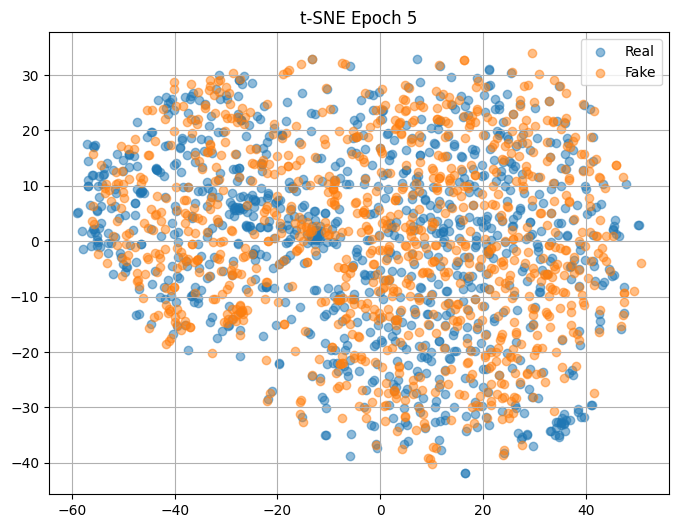

MMD: 0.0024

--- VARIANCE CHECK ---
Real var: 0.0401
Fake var: 0.0351

--- DISCRIMINATOR ACCURACY ---
Real accuracy : 0.3160
Fake accuracy : 0.8940
Total accuracy: 0.6050

--- DISCRIMINATOR ---
Real mean : 0.4743
Fake mean : 0.4279
Gap       : 0.0464


2026-03-24 07:04:29.135223: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 6
D Loss: 1.3437 | G Loss: 1.1420


2026-03-24 07:05:15.844282: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 7
D Loss: 1.3400 | G Loss: 1.1364


2026-03-24 07:06:03.978742: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Epoch 8
D Loss: 1.3382 | G Loss: 1.1444


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.models import load_model
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# =====================================================
# LOAD DATA + MODELS
# =====================================================
X = np.load("hybrid_sequences.npy").astype(np.float32)

idx = np.random.choice(len(X), 50000, replace=False)
X = X[idx]

seq_len    = X.shape[1]
n_features = X.shape[2]
hidden_dim = 64
latent_dim = 24
batch_size = 128

dataset = (tf.data.Dataset
           .from_tensor_slices(X)
           .shuffle(10000)
           .batch(batch_size)
           .prefetch(tf.data.AUTOTUNE))

embedder = load_model("embedder_model.keras")
recovery = load_model("recovery_model.keras")

X_real_eval = X[:1000]

print("Models loaded ✅")

# =====================================================
# MODELS
# =====================================================
def build_generator():
    inputs = layers.Input(shape=(seq_len, latent_dim))
    
    x = layers.GRU(hidden_dim, return_sequences=True)(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.LayerNormalization()(x)

    x = layers.GRU(hidden_dim, return_sequences=True)(x)
    x = layers.GRU(hidden_dim, return_sequences=True)(x)

    return Model(inputs, x)


def build_discriminator():
    inputs = layers.Input(shape=(seq_len, hidden_dim))
    
    x = layers.GRU(hidden_dim)(inputs)
    x = layers.Dropout(0.3)(x)

    return Model(inputs, layers.Dense(1, activation="sigmoid")(x))


generator = build_generator()
discriminator = build_discriminator()

gen_optimizer  = tf.keras.optimizers.Adam(0.0005, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

bce = tf.keras.losses.BinaryCrossentropy()

def get_noise(batch_size):
    return tf.random.uniform([batch_size, seq_len, latent_dim], -1, 1)

# =====================================================
# TRAIN
# =====================================================
@tf.function
def train_step(x):
    batch_size = tf.shape(x)[0]

    # =========================
    # TRAIN DISCRIMINATOR
    # =========================
    z = get_noise(batch_size)

    with tf.GradientTape() as d_tape:
        h_real = embedder(x)
        h_real += tf.random.normal(tf.shape(h_real), stddev=0.05)

        h_fake = generator(z)

        y_real = discriminator(h_real)
        y_fake = discriminator(h_fake)

        d_loss = (
            bce(tf.ones_like(y_real)*0.9, y_real) +
            bce(tf.zeros_like(y_fake), y_fake)
        )

    d_grads = d_tape.gradient(d_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    # =========================
    # TRAIN GENERATOR (FIXED)
    # =========================
    z = get_noise(batch_size)

    with tf.GradientTape() as g_tape:
        h_fake = generator(z)
        h_real = embedder(x)

        # --- Adversarial loss ---
        y_fake = discriminator(h_fake)
        adv_loss = bce(tf.ones_like(y_fake), y_fake)

        # --- Feature matching loss ---
        real_mean = tf.reduce_mean(h_real, axis=0)
        fake_mean = tf.reduce_mean(h_fake, axis=0)

        fm_loss = tf.reduce_mean(tf.abs(real_mean - fake_mean))

        # --- FINAL LOSS ---
        g_loss = adv_loss + 10.0 * fm_loss   # 🔥 key weight

    g_grads = g_tape.gradient(g_loss, generator.trainable_variables)
    gen_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))

    return d_loss, g_loss

# =====================================================
# EVALUATION
# =====================================================
def discriminator_analysis():
    z = get_noise(1000)

    h_fake = generator(z)
    h_real = embedder(X_real_eval)

    y_real = discriminator(h_real).numpy()
    y_fake = discriminator(h_fake).numpy()

    print("\n--- DISCRIMINATOR ---")
    print(f"Real mean : {y_real.mean():.4f}")
    print(f"Fake mean : {y_fake.mean():.4f}")
    print(f"Gap       : {y_real.mean() - y_fake.mean():.4f}")

def discriminator_accuracy():
    z = get_noise(1000)

    h_fake = generator(z)
    h_real = embedder(X_real_eval)

    y_real = discriminator(h_real).numpy()
    y_fake = discriminator(h_fake).numpy()

    # Predictions
    real_preds = (y_real > 0.5).astype(int)
    fake_preds = (y_fake > 0.5).astype(int)

    # Labels
    real_labels = np.ones_like(real_preds)
    fake_labels = np.zeros_like(fake_preds)

    acc_real = (real_preds == real_labels).mean()
    acc_fake = (fake_preds == fake_labels).mean()

    acc_total = (acc_real + acc_fake) / 2

    print("\n--- DISCRIMINATOR ACCURACY ---")
    print(f"Real accuracy : {acc_real:.4f}")
    print(f"Fake accuracy : {acc_fake:.4f}")
    print(f"Total accuracy: {acc_total:.4f}")


def compute_mmd(X_real, X_fake):
    XX = np.dot(X_real, X_real.T)
    YY = np.dot(X_fake, X_fake.T)
    XY = np.dot(X_real, X_fake.T)

    rx = np.diag(XX)
    ry = np.diag(YY)

    K = np.exp(-0.5 * (rx[:, None] + rx[None, :] - 2*XX))
    L = np.exp(-0.5 * (ry[:, None] + ry[None, :] - 2*YY))
    P = np.exp(-0.5 * (rx[:, None] + ry[None, :] - 2*XY))

    return K.mean() + L.mean() - 2*P.mean()
def evaluate(epoch):
    z = get_noise(1000)
    h_fake = generator(z)

    X_fake = recovery(h_fake).numpy().reshape(1000, -1)
    X_real = X_real_eval.reshape(1000, -1)

    X_combined = np.vstack((X_real, X_fake))

    # ---- t-SNE ----
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X_combined)

    plt.figure(figsize=(8,6))
    plt.scatter(X_tsne[:1000,0], X_tsne[:1000,1], label="Real", alpha=0.5)
    plt.scatter(X_tsne[1000:,0], X_tsne[1000:,1], label="Fake", alpha=0.5)
    plt.legend()
    plt.title(f"t-SNE Epoch {epoch}")
    plt.grid()
    plt.show()

    # ---- LDA ----
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    y = np.array([1]*1000 + [0]*1000)

    X_tr, X_te, y_tr, y_te = train_test_split(X_combined, y, test_size=0.3)
    mmd = compute_mmd(X_real, X_fake)
    print(f"MMD: {mmd:.4f}")

    # ---- Variance Check ----
    print("\n--- VARIANCE CHECK ---")
    print(f"Real var: {np.var(X_real):.4f}")
    print(f"Fake var: {np.var(X_fake):.4f}")
    discriminator_accuracy()
    discriminator_analysis()


# =====================================================
# TRAIN LOOP
# =====================================================
print("\n--- TRAINING WITH FULL DIAGNOSTICS ---")

for epoch in range(25):
    d_total, g_total, steps = 0, 0, 0

    for batch in dataset:
        d_loss, g_loss = train_step(batch)
        d_total += d_loss
        g_total += g_loss
        steps += 1

    print(f"\nEpoch {epoch+1}")
    print(f"D Loss: {d_total/steps:.4f} | G Loss: {g_total/steps:.4f}")

    if (epoch+1)%5 == 0:
        evaluate(epoch+1)

print("Done ✅")

In [ ]:
import numpy as np
import tensorflow as tf

# Load small batch
X_sample = X_train[:2048]

# Forward pass
h_real   = embedder(X_sample)
x_recon  = recovery(h_real)

# If supervisor exists
try:
    h_sup = supervisor(h_real)
    sup_exists = True
except:
    sup_exists = False

# --- Metrics ---

# 1. Reconstruction error
recon_mse = np.mean((X_sample - x_recon.numpy())**2)

# 2. Temporal consistency (important for TimeGAN)
temporal_real = np.mean((X_sample[:,1:] - X_sample[:,:-1])**2)
temporal_recon = np.mean((x_recon.numpy()[:,1:] - x_recon.numpy()[:,:-1])**2)

# 3. Latent smoothness
latent_smooth = np.mean((h_real.numpy()[:,1:] - h_real.numpy()[:,:-1])**2)

print("\n--- MODEL SANITY CHECK ---")
print(f"Reconstruction MSE       : {recon_mse:.6f}")
print(f"Real Temporal Diff       : {temporal_real:.6f}")
print(f"Recon Temporal Diff      : {temporal_recon:.6f}")
print(f"Latent Smoothness        : {latent_smooth:.6f}")

# Supervisor check
if sup_exists:
    sup_loss = np.mean((h_real.numpy()[:,1:] - h_sup.numpy()[:,:-1])**2)
    print(f"Supervisor Temporal Loss : {sup_loss:.6f}")

# --- Interpretation ---
print("\n--- INTERPRETATION ---")

if recon_mse > 0.05:
    print("❌ High reconstruction error → Embedder/Recovery need more training")
else:
    print("✅ Reconstruction looks good")

if abs(temporal_real - temporal_recon) > 0.02:
    print("⚠️ Temporal dynamics mismatch → Recovery not learning sequence well")
else:
    print("✅ Temporal structure preserved")

if sup_exists:
    if sup_loss > 0.05:
        print("❌ Supervisor not learning temporal transitions well")
    else:
        print("✅ Supervisor working fine")

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import load_model

# =====================================================
# 1️⃣ LOAD MODELS
# =====================================================
recovery   = load_model("recovery_model.keras")
supervisor = load_model("supervisor_model.keras")
generator  = load_model("generator_model.keras")

seq_len    = 24
latent_dim = 24

def get_noise(batch_size):
    return tf.random.normal([batch_size, seq_len, latent_dim])

print("Loaded ✅")

# =====================================================
# 2️⃣ GENERATE FAKE DATA (normalized space)
# =====================================================
z           = get_noise(5000)
h_fake      = supervisor(generator(z))
X_fake      = recovery(h_fake).numpy().astype(np.float32)
X_fake      = np.clip(X_fake, 0, 1)

np.save("generated_data.npy", X_fake)
print("Generated data saved ✅")

# =====================================================
# 3️⃣ LOAD REAL DATA
# =====================================================
X_real = np.load("hybrid_sequences.npy").astype(np.float32)

n      = min(5000, len(X_real), len(X_fake))
X_real = X_real[:n]
X_fake = X_fake[:n]

print("Real:", X_real.shape)
print("Fake:", X_fake.shape)

# =====================================================
# 4️⃣ FLATTEN
# =====================================================
X_real_flat = X_real.reshape(n, -1)
X_fake_flat = X_fake.reshape(n, -1)
X_combined  = np.vstack((X_real_flat, X_fake_flat))

# =====================================================
# 5️⃣ PCA
# =====================================================
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:n, 0], X_pca[:n, 1], alpha=0.5, label="Real")
plt.scatter(X_pca[n:, 0], X_pca[n:, 1], alpha=0.5, label="Fake")
plt.title("PCA: Real vs Synthetic")
plt.legend(); plt.grid(); plt.show()

# =====================================================
# 6️⃣ t-SNE
# =====================================================
tsne   = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_combined)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:n, 0], X_tsne[:n, 1], alpha=0.5, label="Real")
plt.scatter(X_tsne[n:, 0], X_tsne[n:, 1], alpha=0.5, label="Fake")
plt.title("t-SNE: Real vs Synthetic")
plt.legend(); plt.grid(); plt.show()

# =====================================================
# 7️⃣ DISCRIMINATIVE SCORE
# =====================================================
y_cls = np.array([1]*n + [0]*n)
X_tr, X_te, y_tr, y_te = train_test_split(X_combined, y_cls, test_size=0.3, random_state=42)
clf   = LogisticRegression(max_iter=1000)
clf.fit(X_tr, y_tr)
acc   = accuracy_score(y_te, clf.predict(X_te))

print("\nDiscriminative Score:", acc)
if acc < 0.6:
    print("✅ Excellent GAN")
elif acc < 0.75:
    print("⚠️ Moderate GAN")
else:
    print("❌ Weak GAN")